In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette("husl")

df = pd.read_csv("../data/raw/full_dataset.csv")
print(df.shape)
df.head()

(7005, 3)


,label,text,source
0,smish,আপনি ৩ vori gold জিতেছেন! Claim করুন: +8801716...,CodeMix
1,normal,Tumi ki kheladhula korcho?,Banglish
2,promo,Bonus soho 2GB-45Tk-3din. Dial *121*5534# or m...,Banglish
3,smish,Apnar payment-ta prokria korte amader apnar to...,Banglish
4,smish,জয়! আপনি Google লটারিতে $৫০০০০ জিতেছেন। claim...,Bengali


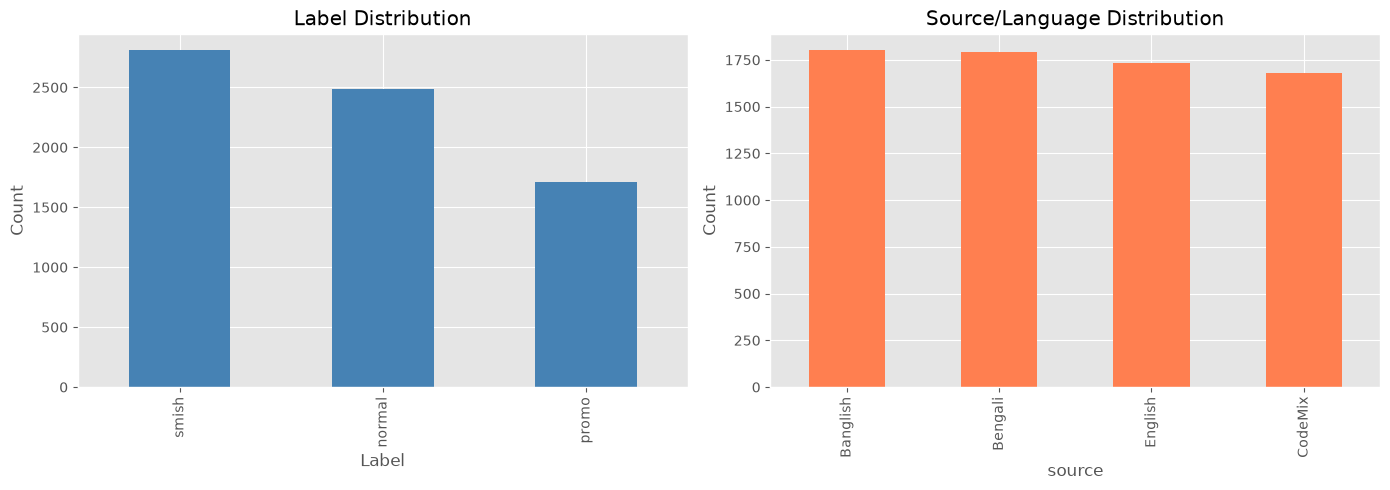

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label distribution
df['label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Label Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

# Source distribution
if 'source' in df.columns:
    df['source'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Source/Language Distribution')
    axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

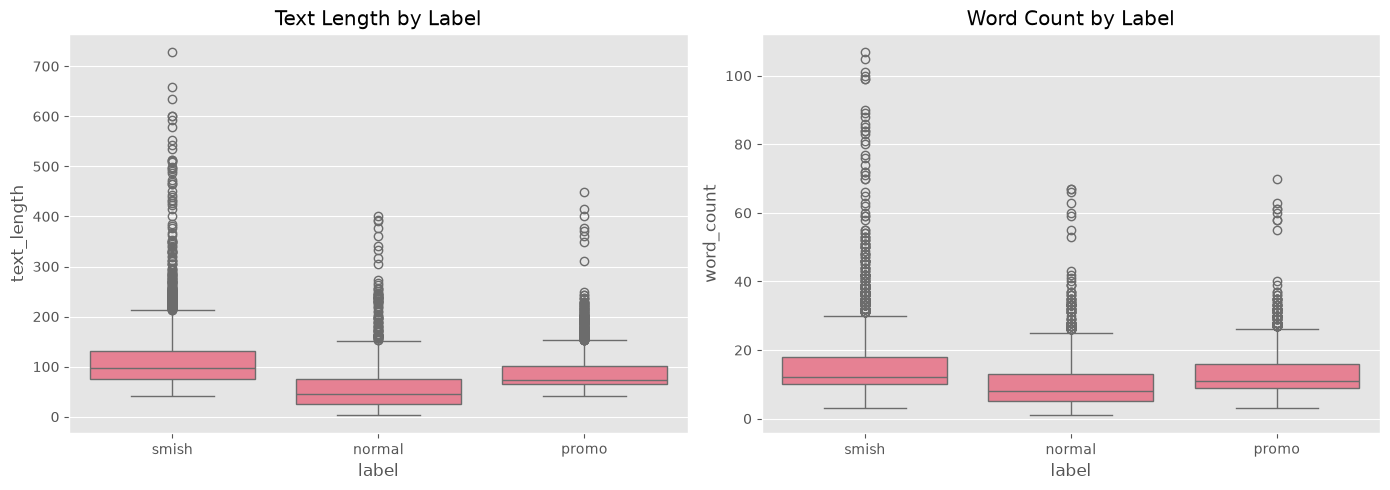

       text_length                                                         \
             count        mean        std   min   25%   50%    75%    max   
label                                                                       
normal      2488.0   57.417203  45.457452   3.0  26.0  45.0   76.0  400.0   
promo       1708.0   90.508782  42.511440  42.0  66.0  73.0  101.0  448.0   
smish       2809.0  115.583482  67.632145  42.0  76.0  97.0  131.0  729.0   

       word_count                                                      
            count       mean        std  min   25%   50%   75%    max  
label                                                                  
normal     2488.0   9.891881   7.421155  1.0   5.0   8.0  13.0   67.0  
promo      1708.0  13.436768   7.139836  3.0   9.0  11.0  16.0   70.0  
smish      2809.0  15.869705  10.863310  3.0  10.0  12.0  18.0  107.0  


In [3]:
df['text_length'] = df['text'].astype(str).str.len()
df['word_count'] = df['text'].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='label', y='text_length', ax=axes[0])
axes[0].set_title('Text Length by Label')

sns.boxplot(data=df, x='label', y='word_count', ax=axes[1])
axes[1].set_title('Word Count by Label')

plt.tight_layout()
plt.savefig('../results/figures/text_length.png', dpi=150, bbox_inches='tight')
plt.show()

# পরিসংখ্যান
print(df.groupby('label')[['text_length', 'word_count']].describe())

In [4]:
for label in df['label'].unique():
    print(f"\n{'='*60}")
    print(f"LABEL: {label}")
    print('='*60)
    samples = df[df['label'] == label].sample(min(3, len(df[df['label']==label])))
    for i, row in samples.iterrows():
        print(f"\n[{row.get('source', 'N/A')}] {row['text'][:200]}")


LABEL: smish

[English] With the smartphone in your hand, if you want to earn online safely 100%, contact us. There is no withdrawal option, no hassle with withdrawal. If you earn one taka, you can cash it out. 100% desatell

[Banglish] Priyojoner mukhe hashi futate dial *213*6551# charge 82.67 protidin

[CodeMix] আপনার credit card-এর information verify করতে হবে। Please এখানে click করুন: http://bit.ly/VerifyCard

LABEL: normal

[English] Any news for me?

[CodeMix] কালকে কি আমাদের viva exam আছে? I need to prepare tonight.

[English] I hope you succeed!

LABEL: promo

[Banglish] Aj Dhanmondi shakhar shubho uddbodhone flat 50% chad! 01896001929 cutt.ly/fmw

[Banglish] Pickaboo smartphone fair: Xiaomi, Realme, Samsung devices up to 7000TK discount plus 6 month EMI. Shop now at pickaboo.com and grab limited stock deals.

[Banglish] Shobar pochonder burger niye Burger King ekhon Dhanmondi 27 e. Deri na kore akorshoniyo shob offer upobhog korte chole ashun Burger King e. Home delivery pete 